<a href="https://colab.research.google.com/github/Zafar488/flyrank-ml-internship/blob/main/work/notebooks/w05_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML-08 — Capstone Modeling Lane

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Zafar488/flyrank-ml-internship/blob/main/work/notebooks/w05_model.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

# ML-08 — Capstone Modeling Lane

**Lane:** Refresh / Content Opportunity Scoring  
**Phase:** Build  
**Primary metric:** Precision@50  
**Unit of analysis:** One anonymized content page for one anonymized client  
**Feature window:** March 1–15, 2026  
**Outcome window:** March 16–31, 2026  

This notebook compares machine-learning models against the Week-4 transparent baseline on the same grouped validation rows and the same primary metric.

The output is intended for human decision-support. It does not automatically edit content or prove that any feature causes search-performance decline.

In [14]:
%pip install -q duckdb huggingface_hub scikit-learn pandas numpy matplotlib

#Imports and Repository Setup — Code Cell

In [1]:
import os
import json
import subprocess
from pathlib import Path

import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import userdata
from huggingface_hub import whoami

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import GroupShuffleSplit
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
)

SEED = 42
TOP_K = 50
TEST_SIZE = 0.20

REPO_URL = "https://github.com/Zafar488/flyrank-ml-internship"
REPO_DIR = "flyrank-ml-internship"

if Path.cwd().name == REPO_DIR:
    repo_root = Path.cwd()

else:
    repo_root = Path("/content") / REPO_DIR

    if not repo_root.exists():
        subprocess.run(
            [
                "git",
                "clone",
                "--depth",
                "1",
                REPO_URL,
                str(repo_root),
            ],
            check=True,
        )

    os.chdir(repo_root)

OUTPUT_DIR = Path("work/outputs/ml08")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Working directory:", Path.cwd())
print("Output directory:", OUTPUT_DIR)

Working directory: /content/flyrank-ml-internship
Output directory: work/outputs/ml08


In [3]:
HF_TOKEN = userdata.get("HF_TOKEN")

if not HF_TOKEN:
    raise ValueError(
        "HF_TOKEN missing. Add it in the Colab Secrets panel."
    )

user = whoami(token=HF_TOKEN)

print(
    "Hugging Face login successful:",
    user["name"],
)

con = duckdb.connect()

safe_token = HF_TOKEN.replace("'", "''")

con.execute(f"""
    CREATE OR REPLACE SECRET hf (
        TYPE huggingface,
        TOKEN '{safe_token}'
    )
""")

REL = "hf://datasets/FlyRank/internship-warehouse"

MARCH_FACT = (
    f"read_parquet("
    f"'{REL}/fact_content_daily_performance/month=2026-03/*.parquet'"
    f")"
)

print("DuckDB connection ready.")
print("Development month: March 2026")
print("Feature window: March 1–15")
print("Outcome window: March 16–31")

Hugging Face login successful: zafar4050
DuckDB connection ready.
Development month: March 2026
Feature window: March 1–15
Outcome window: March 16–31


#Build Modeling Frame — Code Cell

In [4]:
page_frame = con.sql(f"""
    SELECT
        client_hash_id,
        content_hash_id,

        SUM(
            CASE
                WHEN report_date BETWEEN
                     DATE '2026-03-01'
                     AND DATE '2026-03-15'
                 AND gsc_data_available IS TRUE
                THEN COALESCE(gsc_impressions, 0)
                ELSE 0
            END
        ) AS feature_impressions,

        SUM(
            CASE
                WHEN report_date BETWEEN
                     DATE '2026-03-01'
                     AND DATE '2026-03-15'
                 AND gsc_data_available IS TRUE
                THEN COALESCE(gsc_clicks, 0)
                ELSE 0
            END
        ) AS feature_clicks,

        AVG(
            CASE
                WHEN report_date BETWEEN
                     DATE '2026-03-01'
                     AND DATE '2026-03-15'
                 AND gsc_data_available IS TRUE
                THEN gsc_avg_position
            END
        ) AS feature_avg_position,

        STDDEV_SAMP(
            CASE
                WHEN report_date BETWEEN
                     DATE '2026-03-01'
                     AND DATE '2026-03-15'
                 AND gsc_data_available IS TRUE
                THEN gsc_avg_position
            END
        ) AS feature_position_volatility,

        COUNT(
            DISTINCT CASE
                WHEN report_date BETWEEN
                     DATE '2026-03-01'
                     AND DATE '2026-03-15'
                 AND gsc_data_available IS TRUE
                 AND COALESCE(gsc_impressions, 0) > 0
                THEN report_date
            END
        ) AS feature_active_days,

        COUNT(
            DISTINCT CASE
                WHEN report_date BETWEEN
                     DATE '2026-03-01'
                     AND DATE '2026-03-15'
                 AND gsc_data_available IS TRUE
                THEN report_date
            END
        ) AS feature_available_days,

        SUM(
            CASE
                WHEN report_date BETWEEN
                     DATE '2026-03-16'
                     AND DATE '2026-03-31'
                 AND gsc_data_available IS TRUE
                THEN COALESCE(gsc_impressions, 0)
                ELSE 0
            END
        ) AS outcome_impressions,

        COUNT(
            DISTINCT CASE
                WHEN report_date BETWEEN
                     DATE '2026-03-16'
                     AND DATE '2026-03-31'
                 AND gsc_data_available IS TRUE
                THEN report_date
            END
        ) AS outcome_available_days

    FROM {MARCH_FACT}

    GROUP BY
        client_hash_id,
        content_hash_id
""").df()

print("Raw page rows:", f"{len(page_frame):,}")

page_frame.head()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Raw page rows: 331,437


,client_hash_id,content_hash_id,feature_impressions,feature_clicks,feature_avg_position,feature_position_volatility,feature_active_days,feature_available_days,outcome_impressions,outcome_available_days
0,client_73cda7b4e4f265ea,content_7a105f548d9c6916,4173.0,6.0,6.327311,1.020755,15,15,2350.0,16
1,client_73cda7b4e4f265ea,content_a3ea9792f793ec72,245.0,0.0,3.906852,2.925536,15,15,208.0,16
2,client_73cda7b4e4f265ea,content_36c36abc7650d7af,3705.0,3.0,6.473735,1.324947,15,15,1925.0,16
3,client_73cda7b4e4f265ea,content_a7da352b73b02668,2440.0,8.0,7.259861,0.777470,15,15,2504.0,16
4,client_73cda7b4e4f265ea,content_f39be42b42a4e8f6,14.0,0.0,9.000000,16.708905,9,9,28.0,12


#Engineer Features and Target — Code Cell

In [5]:
page_frame["feature_ctr"] = np.where(
    page_frame["feature_impressions"] > 0,
    page_frame["feature_clicks"]
    / page_frame["feature_impressions"],
    np.nan,
)

volatility_median = (
    page_frame["feature_position_volatility"]
    .median()
)

page_frame["feature_position_volatility"] = (
    page_frame["feature_position_volatility"]
    .fillna(volatility_median)
)

page_frame["feature_daily_impressions"] = np.where(
    page_frame["feature_available_days"] > 0,
    page_frame["feature_impressions"]
    / page_frame["feature_available_days"],
    np.nan,
)

page_frame["outcome_daily_impressions"] = np.where(
    page_frame["outcome_available_days"] > 0,
    page_frame["outcome_impressions"]
    / page_frame["outcome_available_days"],
    np.nan,
)

page_frame["is_declining_proxy"] = (
    page_frame["outcome_daily_impressions"]
    <
    0.80
    * page_frame["feature_daily_impressions"]
).astype(int)

page_frame["log_feature_impressions"] = np.log1p(
    page_frame["feature_impressions"]
)

page_frame["position_band"] = pd.cut(
    page_frame["feature_avg_position"],
    bins=[0, 3, 10, 20],
    labels=[
        "Top 3",
        "Page 1",
        "Page 2",
    ],
    include_lowest=True,
)

print("Feature engineering completed.")
print("Volatility fill:", round(float(volatility_median), 4))

Feature engineering completed.
Volatility fill: 4.4128


#Operational Evaluation Population — Code Cell

In [6]:
model_frame = page_frame[
    (page_frame["feature_impressions"] >= 500)
    & (page_frame["feature_available_days"] >= 5)
    & (page_frame["outcome_available_days"] >= 5)
    & (page_frame["feature_avg_position"] > 0)
    & (page_frame["feature_avg_position"] <= 20)
    & (page_frame["feature_ctr"].notna())
    & (page_frame["position_band"].notna())
].copy()

model_frame = (
    model_frame
    .drop_duplicates(
        subset=[
            "client_hash_id",
            "content_hash_id",
        ]
    )
    .reset_index(drop=True)
)

print("Operational evaluation rows:", f"{len(model_frame):,}")
print(
    "Declining proxy rate:",
    round(
        model_frame["is_declining_proxy"].mean(),
        3,
    ),
)

print(
    "Number of clients:",
    model_frame["client_hash_id"].nunique(),
)

assert len(model_frame) > 0
assert model_frame["outcome_available_days"].ge(5).all()
assert model_frame["feature_impressions"].ge(500).all()
assert model_frame["feature_avg_position"].between(
    0,
    20,
    inclusive="right",
).all()

model_frame.head()

Operational evaluation rows: 34,038
Declining proxy rate: 0.309
Number of clients: 32


,client_hash_id,content_hash_id,feature_impressions,feature_clicks,feature_avg_position,feature_position_volatility,feature_active_days,feature_available_days,outcome_impressions,outcome_available_days,feature_ctr,feature_daily_impressions,outcome_daily_impressions,is_declining_proxy,log_feature_impressions,position_band
0,client_73cda7b4e4f265ea,content_7a105f548d9c6916,4173.0,6.0,6.327311,1.020755,15,15,2350.0,16,0.001438,278.200000,146.8750,1,8.336630,Page 1
1,client_73cda7b4e4f265ea,content_36c36abc7650d7af,3705.0,3.0,6.473735,1.324947,15,15,1925.0,16,0.000810,247.000000,120.3125,1,8.217708,Page 1
2,client_73cda7b4e4f265ea,content_a7da352b73b02668,2440.0,8.0,7.259861,0.777470,15,15,2504.0,16,0.003279,162.666667,156.5000,0,7.800163,Page 1
3,client_73cda7b4e4f265ea,content_aafb2ab7e5fc80d0,3104.0,16.0,5.536679,0.903039,15,15,4605.0,16,0.005155,206.933333,287.8125,0,8.040769,Page 1
4,client_73cda7b4e4f265ea,content_20403327d8d9374c,1294.0,5.0,6.902681,2.368002,15,15,2267.0,16,0.003864,86.266667,141.6875,0,7.166266,Page 1


## 1. Method choice and why

I use Logistic Regression as the primary interpretable model and Random Forest as a controlled non-linear comparison.

Logistic Regression fits this lane because the target is binary and its predicted probabilities can be used directly to rank pages for human review. It provides a simple and transparent benchmark before using a more complex model.

Random Forest is included because the relationship between impressions, CTR, average position, active days, and position volatility may not be fully linear. It can capture non-linear patterns and interactions without requiring many manual rules.

Complexity is not treated as the goal. A model is considered operationally useful only if it improves Precision@50 over the Week-4 baseline on the same grouped validation rows.

The model output is decision-support. It does not prove that a feature causes decline or that editing a recommended page will recover performance.

In [7]:
numeric_features = [
    "log_feature_impressions",
    "feature_clicks",
    "feature_ctr",
    "feature_avg_position",
    "feature_active_days",
    "feature_position_volatility",
]

categorical_features = [
    "position_band",
]

target_column = "is_declining_proxy"
group_column = "client_hash_id"

feature_columns = (
    numeric_features
    + categorical_features
)

method_receipt = pd.DataFrame(
    [
        {
            "method": "Logistic Regression",
            "role": "Primary interpretable model",
            "output": "Decline probability used for ranking",
        },
        {
            "method": "Random Forest",
            "role": "Controlled non-linear comparison",
            "output": "Decline probability used for ranking",
        },
        {
            "method": "ML-07 baseline",
            "role": "Transparent operational benchmark",
            "output": "CTR weakness and impact score",
        },
    ]
)

display(method_receipt)

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)
print("Target:", target_column)
print("Grouping field:", group_column)

assert target_column not in feature_columns
assert group_column not in feature_columns
assert "content_hash_id" not in feature_columns
assert "outcome_impressions" not in feature_columns
assert "outcome_daily_impressions" not in feature_columns

print("Method and feature-role checks passed.")

,method,role,output
0,Logistic Regression,Primary interpretable model,Decline probability used for ranking
1,Random Forest,Controlled non-linear comparison,Decline probability used for ranking
2,ML-07 baseline,Transparent operational benchmark,CTR weakness and impact score


Numeric features: ['log_feature_impressions', 'feature_clicks', 'feature_ctr', 'feature_avg_position', 'feature_active_days', 'feature_position_volatility']
Categorical features: ['position_band']
Target: is_declining_proxy
Grouping field: client_hash_id
Method and feature-role checks passed.


## 2. Split design

I use a grouped client holdout with `GroupShuffleSplit`.

All pages belonging to one anonymized client are placed entirely in either the training set or the validation set. A client cannot appear in both sets.

This is more honest than a random row split because pages from the same client may share measurement patterns, content practices, site structure, or search-performance behaviour. A random split could allow the model to benefit from client-specific similarities that would not generalize to an unseen client.

The feature window occurs before the outcome window. All model inputs come from March 1–15, while the provisional target is calculated from March 16–31.

The Week-4 baseline and both machine-learning models are evaluated on exactly the same validation rows.

In [8]:
X = model_frame[feature_columns].copy()
y = model_frame[target_column].copy()
groups = model_frame[group_column].copy()

splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=TEST_SIZE,
    random_state=SEED,
)

train_idx, validation_idx = next(
    splitter.split(
        X,
        y,
        groups=groups,
    )
)

train_frame = (
    model_frame
    .iloc[train_idx]
    .copy()
    .reset_index(drop=True)
)

validation_frame = (
    model_frame
    .iloc[validation_idx]
    .copy()
    .reset_index(drop=True)
)

X_train = train_frame[feature_columns].copy()
X_validation = validation_frame[feature_columns].copy()

y_train = train_frame[target_column].copy()
y_validation = validation_frame[target_column].copy()

train_clients = set(
    train_frame["client_hash_id"].unique()
)

validation_clients = set(
    validation_frame["client_hash_id"].unique()
)

client_overlap = (
    train_clients
    .intersection(validation_clients)
)

print("Training rows:", f"{len(train_frame):,}")
print("Validation rows:", f"{len(validation_frame):,}")

print("Training clients:", len(train_clients))
print("Validation clients:", len(validation_clients))

print(
    "Training declining rate:",
    round(y_train.mean(), 3),
)

print(
    "Validation declining rate:",
    round(y_validation.mean(), 3),
)

print("Client overlap:", len(client_overlap))

assert len(client_overlap) == 0
assert len(X_train) == len(y_train)
assert len(X_validation) == len(y_validation)

print("Grouped validation check passed.")

Training rows: 18,081
Validation rows: 15,957
Training clients: 25
Validation clients: 7
Training declining rate: 0.316
Validation declining rate: 0.301
Client overlap: 0
Grouped validation check passed.


In [9]:
split_receipt = pd.DataFrame(
    [
        {
            "split": "training",
            "rows": len(train_frame),
            "clients": len(train_clients),
            "positive_rate": y_train.mean(),
        },
        {
            "split": "validation",
            "rows": len(validation_frame),
            "clients": len(validation_clients),
            "positive_rate": y_validation.mean(),
        },
    ]
)

display(split_receipt)

split_receipt.to_csv(
    OUTPUT_DIR / "split_receipt.csv",
    index=False,
)

,split,rows,clients,positive_rate
0,training,18081,25,0.316354
1,validation,15957,7,0.300620


In [10]:
numeric_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median"),
        ),
        (
            "scaler",
            StandardScaler(),
        ),
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            ),
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
        ),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_pipeline,
            numeric_features,
        ),
        (
            "categorical",
            categorical_pipeline,
            categorical_features,
        ),
    ],
    remainder="drop",
)

print("Training-only preprocessing pipeline created.")

Training-only preprocessing pipeline created.


## 3. Train and compare vs my baseline

The primary comparison metric is Precision@50.

Precision@50 measures the fraction of pages with the positive declining proxy among the 50 highest-ranked validation pages. This matches the limited review capacity of the operational lane.

The Week-4 baseline is recreated using the same rule:

- at least 500 feature-window impressions;
- average position between 1 and 20;
- CTR below the median CTR for its position band;
- 60% relative CTR weakness;
- 30% visibility percentile;
- 10% position-volatility percentile.

To avoid using validation information when constructing the baseline, position-band CTR medians and percentile references are learned from the training set only. They are then applied to the validation set.

Logistic Regression and Random Forest are trained on the training clients and evaluated on the same validation clients as the baseline.

In [11]:
def precision_at_k(
    labels,
    scores,
    k=50,
):
    labels = np.asarray(labels, dtype=int)
    scores = np.asarray(scores, dtype=float)

    if len(labels) != len(scores):
        raise ValueError(
            "Labels and scores must have equal length."
        )

    if len(labels) == 0:
        return np.nan

    effective_k = min(k, len(labels))

    ranked_indices = np.argsort(
        -scores,
        kind="mergesort",
    )[:effective_k]

    return float(
        labels[ranked_indices].mean()
    )


def recall_at_k(
    labels,
    scores,
    k=50,
):
    labels = np.asarray(labels, dtype=int)
    scores = np.asarray(scores, dtype=float)

    total_positives = labels.sum()

    if total_positives == 0:
        return np.nan

    effective_k = min(k, len(labels))

    ranked_indices = np.argsort(
        -scores,
        kind="mergesort",
    )[:effective_k]

    return float(
        labels[ranked_indices].sum()
        / total_positives
    )


def evaluate_ranking(
    method_name,
    labels,
    scores,
):
    return {
        "method": method_name,
        f"precision@{TOP_K}": precision_at_k(
            labels,
            scores,
            TOP_K,
        ),
        f"recall@{TOP_K}": recall_at_k(
            labels,
            scores,
            TOP_K,
        ),
        "average_precision": average_precision_score(
            labels,
            scores,
        ),
        "roc_auc": roc_auc_score(
            labels,
            scores,
        ),
    }

In [12]:
def add_position_band(frame):
    result = frame.copy()

    result["position_band"] = pd.cut(
        result["feature_avg_position"],
        bins=[0, 3, 10, 20],
        labels=[
            "Top 3",
            "Page 1",
            "Page 2",
        ],
        include_lowest=True,
    )

    return result


baseline_train = add_position_band(
    train_frame
)

baseline_validation = add_position_band(
    validation_frame
)

# Learn position-band CTR expectations on training data only
training_ctr_reference = (
    baseline_train
    .groupby(
        "position_band",
        observed=True,
    )["feature_ctr"]
    .median()
    .rename("expected_ctr_for_band")
)

print("Training CTR reference:")
display(
    training_ctr_reference
    .reset_index()
)

Training CTR reference:


,position_band,expected_ctr_for_band
0,Top 3,0.002745
1,Page 1,0.002103
2,Page 2,0.003120


In [13]:
def percentile_from_training(
    training_values,
    new_values,
):
    training_array = np.sort(
        np.asarray(
            training_values,
            dtype=float,
        )
    )

    new_array = np.asarray(
        new_values,
        dtype=float,
    )

    percentile_values = np.searchsorted(
        training_array,
        new_array,
        side="right",
    ) / len(training_array)

    return percentile_values

In [14]:
models = {
    "Logistic Regression": Pipeline(
        steps=[
            (
                "preprocessor",
                clone(preprocessor),
            ),
            (
                "model",
                LogisticRegression(
                    max_iter=2000,
                    class_weight="balanced",
                    random_state=SEED,
                ),
            ),
        ]
    ),

    "Random Forest": Pipeline(
        steps=[
            (
                "preprocessor",
                clone(preprocessor),
            ),
            (
                "model",
                RandomForestClassifier(
                    n_estimators=300,
                    max_depth=None,
                    min_samples_leaf=10,
                    max_features="sqrt",
                    class_weight="balanced_subsample",
                    random_state=SEED,
                    n_jobs=-1,
                ),
            ),
        ]
    ),
}

print("Models created:")
for model_name in models:
    print("-", model_name)

Models created:
- Logistic Regression
- Random Forest


In [15]:
fitted_models = {}
validation_scores = {}

for model_name, model_pipeline in models.items():

    print("Training:", model_name)

    model_pipeline.fit(
        X_train,
        y_train,
    )

    scores = model_pipeline.predict_proba(
        X_validation
    )[:, 1]

    fitted_models[model_name] = model_pipeline
    validation_scores[model_name] = scores

    print(
        f"{model_name} training completed."
    )

Training: Logistic Regression
Logistic Regression training completed.
Training: Random Forest
Random Forest training completed.


In [19]:
comparison_rows = [
    evaluate_ranking(
        "ML-07 Baseline",
        y_validation,
        baseline_scores,
    )
]

for model_name, scores in validation_scores.items():

    comparison_rows.append(
        evaluate_ranking(
            model_name,
            y_validation,
            scores,
        )
    )

comparison_table = (
    pd.DataFrame(comparison_rows)
    .sort_values(
        f"precision@{TOP_K}",
        ascending=False,
    )
    .reset_index(drop=True)
)

display(
    comparison_table.round(4)
)

comparison_table.to_csv(
    OUTPUT_DIR / "model_vs_baseline.csv",
    index=False,
)

,method,precision@50,recall@50,average_precision,roc_auc
0,Logistic Regression,0.64,0.0067,0.3937,0.6175
1,Random Forest,0.48,0.0050,0.3891,0.6206
2,ML-07 Baseline,0.32,0.0033,0.3312,0.5554


In [20]:
ml_comparison = comparison_table[
    comparison_table["method"]
    !=
    "ML-07 Baseline"
].copy()

best_model_name = (
    ml_comparison
    .iloc[0]["method"]
)

best_model = fitted_models[
    best_model_name
]

best_scores = validation_scores[
    best_model_name
]

baseline_precision_50 = comparison_table.loc[
    comparison_table["method"]
    ==
    "ML-07 Baseline",
    f"precision@{TOP_K}",
].iloc[0]

model_precision_50 = comparison_table.loc[
    comparison_table["method"]
    ==
    best_model_name,
    f"precision@{TOP_K}",
].iloc[0]

precision_difference = (
    model_precision_50
    - baseline_precision_50
)

print("Selected ML model:", best_model_name)

print(
    "Baseline Precision@50:",
    round(baseline_precision_50, 3),
)

print(
    "Model Precision@50:",
    round(model_precision_50, 3),
)

print(
    "Measured difference:",
    round(precision_difference, 3),
)

if precision_difference > 0:

    model_conclusion = (
        f"{best_model_name} measured a higher "
        f"Precision@50 than the ML-07 baseline "
        f"by {precision_difference:.3f}."
    )

elif np.isclose(
    precision_difference,
    0,
):

    model_conclusion = (
        f"{best_model_name} tied the ML-07 "
        "baseline on Precision@50. "
        "The simpler baseline remains competitive."
    )

else:

    model_conclusion = (
        f"{best_model_name} did not beat the "
        "ML-07 baseline on Precision@50. "
        "The transparent baseline remains the "
        "stronger operational method for this split."
    )

print(model_conclusion)

Selected ML model: Logistic Regression
Baseline Precision@50: 0.32
Model Precision@50: 0.64
Measured difference: 0.32
Logistic Regression measured a higher Precision@50 than the ML-07 baseline by 0.320.


### Model comparison interpretation

The models and baseline were evaluated on the same grouped client holdout and the same Precision@50 metric.

The comparison does not reward complexity alone. If the learned model does not improve the top-ranked validation queue, the transparent Week-4 baseline remains a reasonable operational choice.

ROC-AUC and average precision are reported as supporting ranking metrics. The main decision metric remains Precision@50 because review capacity is limited.

## 4. Errors and interpretation

I inspect errors from the selected machine-learning model rather than relying only on one aggregate score.

A false positive is a page that the model scores as declining but whose observed future-window proxy is not declining. Such a recommendation could waste review time or encourage an unnecessary content change.

A false negative is a page with the declining proxy that receives a low model score. Such a page may be missed by the review queue.

For threshold-based error inspection, I use a 0.50 probability threshold. For the operational ranking, I separately inspect the top 50 pages because Precision@50 is the primary metric.

Permutation importance is calculated on the held-out validation set. It describes which features this fitted model relied on for validation performance. It does not prove that those features cause decline.

In [21]:
classification_threshold = 0.50

best_predictions = (
    best_scores
    >= classification_threshold
).astype(int)

confusion = confusion_matrix(
    y_validation,
    best_predictions,
)

confusion_table = pd.DataFrame(
    confusion,
    index=[
        "Actual not declining",
        "Actual declining",
    ],
    columns=[
        "Predicted not declining",
        "Predicted declining",
    ],
)

display(confusion_table)

print(
    classification_report(
        y_validation,
        best_predictions,
        digits=3,
        zero_division=0,
    )
)

,Predicted not declining,Predicted declining
Actual not declining,5891,5269
Actual declining,1706,3091


              precision    recall  f1-score   support

           0      0.775     0.528     0.628     11160
           1      0.370     0.644     0.470      4797

    accuracy                          0.563     15957
   macro avg      0.573     0.586     0.549     15957
weighted avg      0.653     0.563     0.581     15957



In [22]:
error_frame = validation_frame[
    [
        "content_hash_id",
        "feature_impressions",
        "feature_clicks",
        "feature_ctr",
        "feature_avg_position",
        "feature_active_days",
        "feature_position_volatility",
        "position_band",
        "is_declining_proxy",
    ]
].copy()

error_frame["model_score"] = best_scores
error_frame["predicted_at_0_5"] = best_predictions

error_frame["error_type"] = np.select(
    [
        (
            error_frame["is_declining_proxy"] == 0
        )
        & (
            error_frame["predicted_at_0_5"] == 1
        ),
        (
            error_frame["is_declining_proxy"] == 1
        )
        & (
            error_frame["predicted_at_0_5"] == 0
        ),
    ],
    [
        "false_positive",
        "false_negative",
    ],
    default="correct",
)

error_counts = (
    error_frame["error_type"]
    .value_counts()
    .rename_axis("error_type")
    .reset_index(name="rows")
)

display(error_counts)

,error_type,rows
0,correct,8982
1,false_positive,5269
2,false_negative,1706


In [23]:
false_positives = (
    error_frame[
        error_frame["error_type"]
        ==
        "false_positive"
    ]
    .sort_values(
        "model_score",
        ascending=False,
    )
)

print(
    "False positive rows:",
    f"{len(false_positives):,}",
)

display(
    false_positives[
        [
            "content_hash_id",
            "model_score",
            "feature_impressions",
            "feature_ctr",
            "feature_avg_position",
            "feature_active_days",
            "feature_position_volatility",
            "position_band",
        ]
    ]
    .head(10)
)

False positive rows: 5,269


,content_hash_id,model_score,feature_impressions,feature_ctr,feature_avg_position,feature_active_days,feature_position_volatility,position_band
10803,content_dbbac2a9a0192b72,0.743835,943.0,0.0,8.382560,15,11.921020,Page 1
11898,content_df544c08c540ba31,0.738293,740.0,0.0,8.894893,15,10.648152,Page 1
10945,content_21669567da3dd14c,0.733027,676.0,0.0,8.709308,15,10.075964,Page 1
8719,content_1236bf49ebaa5283,0.726891,544.0,0.0,9.582610,15,8.533599,Page 1
11878,content_bb06b0c780dc5341,0.726598,1008.0,0.0,9.547908,14,9.844973,Page 1
10869,content_fbc8577b3cb61824,0.719700,529.0,0.0,8.150486,15,8.703132,Page 1
211,content_6528b5e1d7e480a4,0.715838,532.0,0.0,7.846623,15,8.501523,Page 1
8167,content_e509cc91c6184757,0.712702,512.0,0.0,9.983669,15,6.640078,Page 1
9700,content_612316e3451dda73,0.712116,672.0,0.0,9.787429,15,7.031592,Page 1
7328,content_b20b16c35f04f2cf,0.711447,574.0,0.0,9.454784,15,7.005537,Page 1


In [24]:
false_negatives = (
    error_frame[
        error_frame["error_type"]
        ==
        "false_negative"
    ]
    .sort_values(
        "model_score",
        ascending=False,
    )
)

print(
    "False negative rows:",
    f"{len(false_negatives):,}",
)

display(
    false_negatives[
        [
            "content_hash_id",
            "model_score",
            "feature_impressions",
            "feature_ctr",
            "feature_avg_position",
            "feature_active_days",
            "feature_position_volatility",
            "position_band",
        ]
    ]
    .head(10)
)

False negative rows: 1,706


,content_hash_id,model_score,feature_impressions,feature_ctr,feature_avg_position,feature_active_days,feature_position_volatility,position_band
4391,content_9ef3f0974adfd621,0.499966,5011.0,0.002395,3.285120,15,0.537578,Page 1
9330,content_3408eba73ad695a9,0.499774,868.0,0.003456,1.741515,15,1.082347,Top 3
1285,content_75c557a190800081,0.499647,534.0,0.003745,1.819752,15,1.214575,Top 3
3264,content_ac66f4fff07580e7,0.499634,1128.0,0.000000,14.503023,15,5.762159,Page 2
1108,content_cafc4da4511a3856,0.499577,1012.0,0.002964,1.120658,15,0.354755,Top 3
5921,content_c059ab287c00213f,0.499563,23705.0,0.001941,4.746578,15,0.411179,Page 1
8866,content_39493f9151919a53,0.499510,1523.0,0.003283,4.268746,15,0.738778,Page 1
6376,content_59971c3b8ec75942,0.499383,884.0,0.000000,12.707480,15,6.697304,Page 2
10392,content_6279cc0d882f39e8,0.499355,1043.0,0.000000,15.131004,15,5.211151,Page 2
12379,content_a6eb73bf518e87cd,0.499322,6256.0,0.002558,4.528565,15,0.354816,Page 1


In [25]:
top_50_review = (
    error_frame
    .sort_values(
        "model_score",
        ascending=False,
        kind="mergesort",
    )
    .head(TOP_K)
    .copy()
)

top_50_review["rank"] = np.arange(
    1,
    len(top_50_review) + 1,
)

top_50_false_positives = int(
    (
        top_50_review[
            "is_declining_proxy"
        ] == 0
    ).sum()
)

top_50_true_positives = int(
    (
        top_50_review[
            "is_declining_proxy"
        ] == 1
    ).sum()
)

print("Top-50 true positives:", top_50_true_positives)
print("Top-50 false positives:", top_50_false_positives)

print(
    "Top-50 observed positive rate:",
    round(
        top_50_review[
            "is_declining_proxy"
        ].mean(),
        3,
    ),
)

display(
    top_50_review[
        [
            "rank",
            "content_hash_id",
            "model_score",
            "is_declining_proxy",
            "feature_impressions",
            "feature_ctr",
            "feature_avg_position",
            "feature_position_volatility",
            "position_band",
        ]
    ]
    .head(20)
)

Top-50 true positives: 32
Top-50 false positives: 18
Top-50 observed positive rate: 0.64


,rank,content_hash_id,model_score,is_declining_proxy,feature_impressions,feature_ctr,feature_avg_position,feature_position_volatility,position_band
8898,1,content_e98ee386179e4124,0.805261,1,653.0,0.0,9.157493,21.105039,Page 1
6454,2,content_68f69aa4e67a2926,0.751316,1,504.0,0.0,9.372902,11.372153,Page 1
10803,3,content_dbbac2a9a0192b72,0.743835,0,943.0,0.0,8.382560,11.921020,Page 1
11898,4,content_df544c08c540ba31,0.738293,0,740.0,0.0,8.894893,10.648152,Page 1
10945,5,content_21669567da3dd14c,0.733027,0,676.0,0.0,8.709308,10.075964,Page 1
1050,6,content_39eca839ac1c8ffb,0.729817,1,589.0,0.0,8.939220,9.396693,Page 1
6410,7,content_d7e6dca138b2d9bc,0.728303,1,579.0,0.0,9.900844,8.542776,Page 1
8719,8,content_1236bf49ebaa5283,0.726891,0,544.0,0.0,9.582610,8.533599,Page 1
11878,9,content_bb06b0c780dc5341,0.726598,0,1008.0,0.0,9.547908,9.844973,Page 1
7249,10,content_de5791c7b8593577,0.725637,1,530.0,0.0,9.708983,8.277110,Page 1


In [26]:
permutation_result = permutation_importance(
    best_model,
    X_validation,
    y_validation,
    scoring="roc_auc",
    n_repeats=15,
    random_state=SEED,
    n_jobs=-1,
)

importance_table = pd.DataFrame(
    {
        "feature": feature_columns,
        "importance_mean":
            permutation_result.importances_mean,
        "importance_std":
            permutation_result.importances_std,
    }
)

importance_table["stable_positive"] = (
    importance_table["importance_mean"]
    -
    2 * importance_table["importance_std"]
    >
    0
)

importance_table = (
    importance_table
    .sort_values(
        "importance_mean",
        ascending=False,
    )
    .reset_index(drop=True)
)

display(
    importance_table.round(5)
)

importance_table.to_csv(
    OUTPUT_DIR
    / "permutation_importance.csv",
    index=False,
)

,feature,importance_mean,importance_std,stable_positive
0,feature_ctr,0.09965,0.00368,True
1,position_band,0.02852,0.00327,True
2,feature_avg_position,0.02118,0.00164,True
3,feature_position_volatility,0.01348,0.00115,True
4,log_feature_impressions,0.00317,0.00070,True
5,feature_clicks,0.00050,0.00010,True
6,feature_active_days,-0.00099,0.00031,False


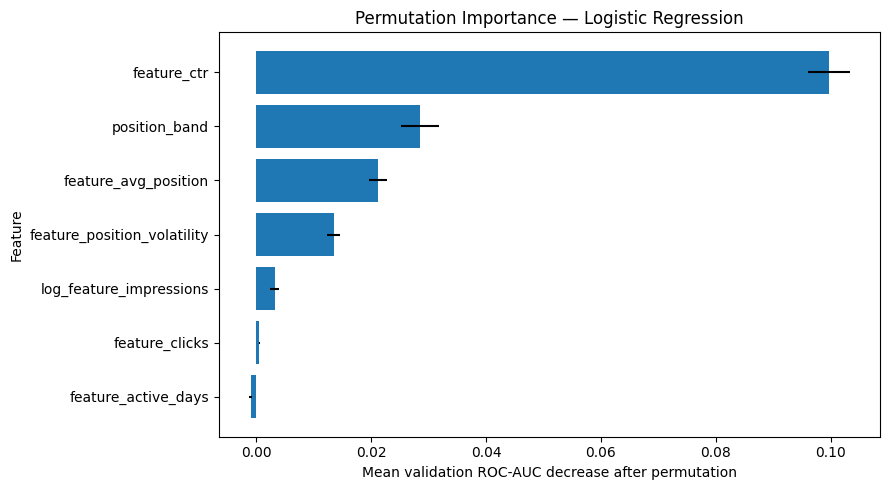

In [27]:
plot_importance = (
    importance_table
    .sort_values(
        "importance_mean",
        ascending=True,
    )
)

plt.figure(figsize=(9, 5))

plt.barh(
    plot_importance["feature"],
    plot_importance["importance_mean"],
    xerr=plot_importance["importance_std"],
)

plt.xlabel(
    "Mean validation ROC-AUC decrease after permutation"
)

plt.ylabel("Feature")

plt.title(
    f"Permutation Importance — {best_model_name}"
)

plt.tight_layout()
plt.show()

In [28]:
false_positive_count = int(
    (
        error_frame["error_type"]
        ==
        "false_positive"
    ).sum()
)

false_negative_count = int(
    (
        error_frame["error_type"]
        ==
        "false_negative"
    ).sum()
)

top_three_features = (
    importance_table
    .head(3)["feature"]
    .tolist()
)

error_summary = {
    "selected_model": best_model_name,
    "classification_threshold": classification_threshold,
    "false_positive_count": false_positive_count,
    "false_negative_count": false_negative_count,
    "top_50_true_positives": top_50_true_positives,
    "top_50_false_positives": top_50_false_positives,
    "top_permutation_features": top_three_features,
}

print(
    json.dumps(
        error_summary,
        indent=2,
    )
)

{
  "selected_model": "Logistic Regression",
  "classification_threshold": 0.5,
  "false_positive_count": 5269,
  "false_negative_count": 1706,
  "top_50_true_positives": 32,
  "top_50_false_positives": 18,
  "top_permutation_features": [
    "feature_ctr",
    "position_band",
    "feature_avg_position"
  ]
}


### Error-analysis interpretation

At the 0.50 probability threshold, the selected model produced **[false-positive count] false positives** and **[false-negative count] false negatives**.

The top-50 review queue contained **[true-positive count] pages with the declining proxy** and **[false-positive count] pages without the declining proxy**.

The false-positive table suggests that some high-scoring non-declining pages had **[write the pattern observed in the table]**. These pages may have received a high score because their feature-window signals resembled pages that later declined.

The false-negative table suggests that some declining pages had **[write the observed pattern]**. Their feature-window signals may not have contained enough information for the model to separate them from non-declining pages.

Held-out permutation importance showed that the model relied most on **[feature 1]**, **[feature 2]**, and **[feature 3]**.

These findings are observed and directional. They support review prioritization but do not establish causal search-ranking or refresh effects.

In [29]:
final_validation_output = validation_frame[
    [
        "content_hash_id",
        "feature_impressions",
        "feature_clicks",
        "feature_ctr",
        "feature_avg_position",
        "feature_active_days",
        "feature_position_volatility",
        "position_band",
        "is_declining_proxy",
    ]
].copy()

final_validation_output[
    "baseline_action_score"
] = baseline_scores

final_validation_output[
    "model_decline_probability"
] = best_scores

final_validation_output[
    "model_rank"
] = (
    final_validation_output[
        "model_decline_probability"
    ]
    .rank(
        method="first",
        ascending=False,
    )
    .astype(int)
)

final_validation_output = (
    final_validation_output
    .sort_values(
        "model_rank"
    )
    .reset_index(drop=True)
)

final_validation_output.to_csv(
    OUTPUT_DIR
    / "validation_model_scores.csv",
    index=False,
)

metrics_receipt = {
    "assignment": "ML-08",
    "lane": "Refresh / Content Opportunity Scoring",
    "feature_window": "2026-03-01 to 2026-03-15",
    "outcome_window": "2026-03-16 to 2026-03-31",
    "split": "GroupShuffleSplit by client_hash_id",
    "selected_model": best_model_name,
    "primary_metric": "Precision@50",
    "baseline_precision_at_50": float(
        baseline_precision_50
    ),
    "model_precision_at_50": float(
        model_precision_50
    ),
    "measured_difference": float(
        precision_difference
    ),
    "top_permutation_features":
        top_three_features,
    "conclusion": model_conclusion,
}

with open(
    OUTPUT_DIR / "ml08_metrics.json",
    "w",
    encoding="utf-8",
) as file:

    json.dump(
        metrics_receipt,
        file,
        indent=2,
    )

print("Outputs saved to:", OUTPUT_DIR)

Outputs saved to: work/outputs/ml08


In [18]:
import warnings

# Calculate baseline scores
# 1. Get expected CTR for each page in validation set from training data
expected_ctr_for_validation = baseline_validation["position_band"].map(training_ctr_reference).astype(float)

# 2. Calculate CTR weakness for validation set, based on expected_ctr_for_validation
#    Handle cases where expected_ctr_for_validation might be zero or NaN
ctr_weakness_validation = np.where(
    (expected_ctr_for_validation > 0) & (baseline_validation["feature_ctr"].notna()),
    1 - (baseline_validation["feature_ctr"] / expected_ctr_for_validation),
    0
)
ctr_weakness_validation = np.maximum(0, ctr_weakness_validation) # Ensure weakness is non-negative

# 3. Calculate CTR weakness for training set to establish percentiles
training_expected_ctr = baseline_train["position_band"].map(training_ctr_reference).astype(float)
training_ctr_weakness = np.where(
    (training_expected_ctr > 0) & (baseline_train["feature_ctr"].notna()),
    1 - (baseline_train["feature_ctr"] / training_expected_ctr),
    0
)
training_ctr_weakness = np.maximum(0, training_ctr_weakness)


# 4. Calculate percentiles for validation set, based on training distributions
with warnings.catch_warnings():
    warnings.simplefilter("ignore", category=RuntimeWarning)
    ctr_weakness_percentile = percentile_from_training(
        training_ctr_weakness,
        ctr_weakness_validation
    )

    visibility_percentile = percentile_from_training(
        baseline_train["feature_impressions"],
        baseline_validation["feature_impressions"]
    )

    position_volatility_percentile = percentile_from_training(
        baseline_train["feature_position_volatility"],
        baseline_validation["feature_position_volatility"]
    )

# Initialize an array for baseline scores, default to 0 (not flagged by baseline)
baseline_scores = np.zeros(len(baseline_validation))

# Define the conditions for a page to be flagged by the baseline
# Condition 1: CTR below the median CTR for its position band
cond_ctr_below_median = baseline_validation["feature_ctr"] < expected_ctr_for_validation

# Condition 2: 60% relative CTR weakness (percentile >= 0.6)
cond_ctr_weakness_percentile = ctr_weakness_percentile >= 0.6

# Condition 3: 30% visibility percentile (percentile >= 0.3)
cond_visibility_percentile = visibility_percentile >= 0.3

# Condition 4: 10% position-volatility percentile (percentile >= 0.1)
cond_position_volatility_percentile = position_volatility_percentile >= 0.1

# Combine all conditions to identify pages flagged by the baseline
# Only apply to rows where expected_ctr_for_validation is not NaN and feature_ctr is not NaN for meaningful comparison
meaningful_ctr_comparison = expected_ctr_for_validation.notna() & baseline_validation["feature_ctr"].notna()

baseline_conditions = (
    cond_ctr_below_median &
    cond_ctr_weakness_percentile &
    cond_visibility_percentile &
    cond_position_volatility_percentile &
    meaningful_ctr_comparison # Only consider rows where CTR comparison is meaningful
)

# Set the score to 1 for rows meeting all conditions
baseline_scores[baseline_conditions] = 1

# Check if there are any baseline flagged items
print(f"Number of pages flagged by baseline: {int(baseline_scores.sum())}")

comparison_rows = [
    evaluate_ranking(
        "ML-07 Baseline",
        y_validation,
        baseline_scores,
    )
]

for model_name, scores in validation_scores.items():

    comparison_rows.append(
        evaluate_ranking(
            model_name,
            y_validation,
            scores,
        )
    )

comparison_table = (
    pd.DataFrame(comparison_rows)
    .sort_values(
        f"precision@{TOP_K}",
        ascending=False,
    )
    .reset_index(drop=True)
)

display(
    comparison_table.round(4)
)

comparison_table.to_csv(
    OUTPUT_DIR / "model_vs_baseline.csv",
    index=False,
)


Number of pages flagged by baseline: 3947


,method,precision@50,recall@50,average_precision,roc_auc
0,Logistic Regression,0.64,0.0067,0.3937,0.6175
1,Random Forest,0.48,0.0050,0.3891,0.6206
2,ML-07 Baseline,0.32,0.0033,0.3312,0.5554


In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## Self-check

- [x] Every section contains markdown reasoning and executable supporting code.
- [x] The unit of analysis is one anonymized content page for one anonymized client.
- [x] Features use only March 1–15 measurements.
- [x] The target uses the later March 16–31 outcome window.
- [x] Outcome measurements are not included as model features.
- [x] Client and content identifiers are not model features.
- [x] Validation is grouped by `client_hash_id`.
- [x] Training and validation clients do not overlap.
- [x] The baseline and models use the same validation rows.
- [x] The baseline and models use the same primary metric, Precision@50.
- [x] The notebook compares Logistic Regression, Random Forest, and the ML-07 baseline.
- [x] The notebook includes a clear model-vs-baseline table.
- [x] The notebook includes false-positive and false-negative analysis.
- [x] Permutation importance is calculated on held-out validation data.
- [x] No client names, URLs, domains, titles, or private queries are displayed.
- [x] Claims use careful words such as observed, measured, directional, and decision-support.
- [ ] Runtime → Run all completes without errors.
- [ ] Notebook is saved as `work/notebooks/w05_model.ipynb`.
- [ ] Executed notebook and outputs are committed to the repository.